In [1]:
# import features
import pandas as pd
# acitvity entropy
df_entropy = pd.read_csv('../output/data_cleaned/activity_entropy_rates.csv')
print(df_entropy.shape)

# early warning scores (physiological)
df_EWS = pd.read_csv('../output/data_cleaned/Mian_warning_score.csv')
df_EWS.columns = ['patient_id', 'date', 'early_warning_score']


# sleep quality
df_sleep_quality = pd.read_csv('../output/sleep_score/sleep_quality_score_by_duration.csv')
df_sleep_quality = df_sleep_quality.drop(columns= ['sum', 'mean','scaled_sleep_quality_sum']).copy()
df_sleep_quality.columns = ['patient_id', 'date', 'sleep_quality_score']

# agitation
df_agitation = pd.read_csv('../output/data_cleaned/agitation_daily_counts.csv')

# uti
df_uti = pd.read_csv('../output/data_cleaned/uti_daily.csv')

merged_df = df_entropy
# merge dataframes
for df in [df_EWS, df_sleep_quality, df_agitation, df_uti]:
    print(df.shape)
    merged_df = pd.merge(merged_df, df, on=['patient_id', 'date'], how='outer')
    
# only consider the patients without NA in the following analysis (as the analysis itself will be individualized anyway)
analysis_df = merged_df.dropna(subset=['sleep_quality_score']).dropna(subset=['early_warning_score']).dropna(subset=['entropy_rate']).copy()
analysis_df =  analysis_df.fillna(0)

print(analysis_df.shape)
analysis_df 

(2722, 3)
(2160, 3)
(800, 3)
(115, 3)
(265, 3)
(660, 7)


,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
219,0f352,2019-06-26,0.669008,0.0,2.233437,0.0,1.0
221,0f352,2019-06-28,0.613697,0.0,1.516700,0.0,0.0
222,0f352,2019-06-29,0.615494,0.0,-0.010261,0.0,1.0
223,0f352,2019-06-30,0.514768,0.0,2.607387,0.0,0.0
250,16f4b,2019-04-28,0.651879,0.0,-1.319084,0.0,0.0
...,...,...,...,...,...,...,...
2694,f220c,2019-06-06,0.620975,0.0,-2.627908,0.0,0.0
2696,f220c,2019-06-08,0.527123,0.0,2.607387,0.0,0.0
2706,f220c,2019-06-19,0.527442,0.0,2.607387,0.0,0.0
2709,f220c,2019-06-22,0.608841,0.0,2.607387,0.0,0.0


In [2]:
analysis_df['patient_id'].value_counts()

c55f8    79
ec812    70
c5785    66
55cd4    64
30a32    62
a2849    57
1fbe4    52
96adf    49
c8574    45
93c14    36
e2472    25
f220c    15
16f4b    13
d7a46    10
b0455     9
76230     4
0f352     4
Name: patient_id, dtype: int64

In [3]:
id_select = "ec812"
df_person = analysis_df[analysis_df['patient_id'] == id_select].copy()
df_person 

,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
2528,ec812,2019-04-09,0.684974,0.0,-0.010261,0.0,0.0
2529,ec812,2019-04-10,0.614688,0.0,0.316945,0.0,0.0
2530,ec812,2019-04-11,0.680348,0.0,-0.446535,0.0,0.0
2531,ec812,2019-04-12,0.668105,0.0,-0.337467,0.0,0.0
2532,ec812,2019-04-13,0.655223,0.0,0.363689,0.0,0.0
...,...,...,...,...,...,...,...
2594,ec812,2019-06-21,0.661363,0.0,-0.337467,0.0,0.0
2595,ec812,2019-06-22,0.623560,0.0,0.862288,0.0,0.0
2596,ec812,2019-06-23,0.708682,0.0,0.316945,0.0,0.0
2597,ec812,2019-06-24,0.656330,0.0,0.280589,0.0,0.0


In [4]:
from sklearn.preprocessing import StandardScaler
data = df_person.copy()
features = data[['entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_features_df

,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
0,0.115931,-0.246183,-0.009237,-0.211604,-0.246183
1,-1.846025,-0.246183,0.482444,-0.211604,-0.246183
2,-0.013188,-0.246183,-0.664813,-0.211604,-0.246183
3,-0.354931,-0.246183,-0.500919,-0.211604,-0.246183
4,-0.714537,-0.246183,0.552684,-0.211604,-0.246183
...,...,...,...,...,...
65,-0.543135,-0.246183,-0.500919,-0.211604,-0.246183
66,-1.598379,-0.246183,1.301913,-0.211604,-0.246183
67,0.777736,-0.246183,0.482444,-0.211604,-0.246183
68,-0.683621,-0.246183,0.427813,-0.211604,-0.246183


In [5]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from ucimlrepo import fetch_ucirepo

# Parameters
n_estimators = 100  # Number of trees
contamination = 0.1  # Expected proportion of anomalies
sample_size = 30  # Number of samples used to train each tree

# Train Isolation Forest
iso_forest = IsolationForest(n_estimators=n_estimators,
                            contamination=contamination,
                            max_samples=sample_size,
                            random_state=42)

iso_forest.fit(scaled_features_df)

# Calculate anomaly scores and classify anomalies

data['anomaly_score'] = iso_forest.decision_function(scaled_features_df)
data['anomaly'] = iso_forest.predict(scaled_features_df)

data['anomaly'].value_counts()

C:\Users\lpxcm13\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


 1    63
-1     7
Name: anomaly, dtype: int64

In [6]:
anomaly_dates = pd.to_datetime(data[data.anomaly == -1].date).dt.strftime('%m-%d').astype(str).values
anomaly_dates

array(['04-17', '04-22', '04-24', '04-26', '05-06', '05-08', '06-07'],
      dtype=object)

In [7]:
data_plot = data[['date', 'entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen']].copy()

data_plot['date'] = pd.to_datetime(data_plot['date'])            
data_plot['date'] = data_plot['date'].dt.strftime('%m-%d')
data_plot['date'] = data_plot['date'].astype(str)             
data_plot.set_index('date', inplace=True)

data_plot

,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
date,,,,,
04-09,0.684974,0.0,-0.010261,0.0,0.0
04-10,0.614688,0.0,0.316945,0.0,0.0
04-11,0.680348,0.0,-0.446535,0.0,0.0
04-12,0.668105,0.0,-0.337467,0.0,0.0
04-13,0.655223,0.0,0.363689,0.0,0.0
...,...,...,...,...,...
06-21,0.661363,0.0,-0.337467,0.0,0.0
06-22,0.623560,0.0,0.862288,0.0,0.0
06-23,0.708682,0.0,0.316945,0.0,0.0


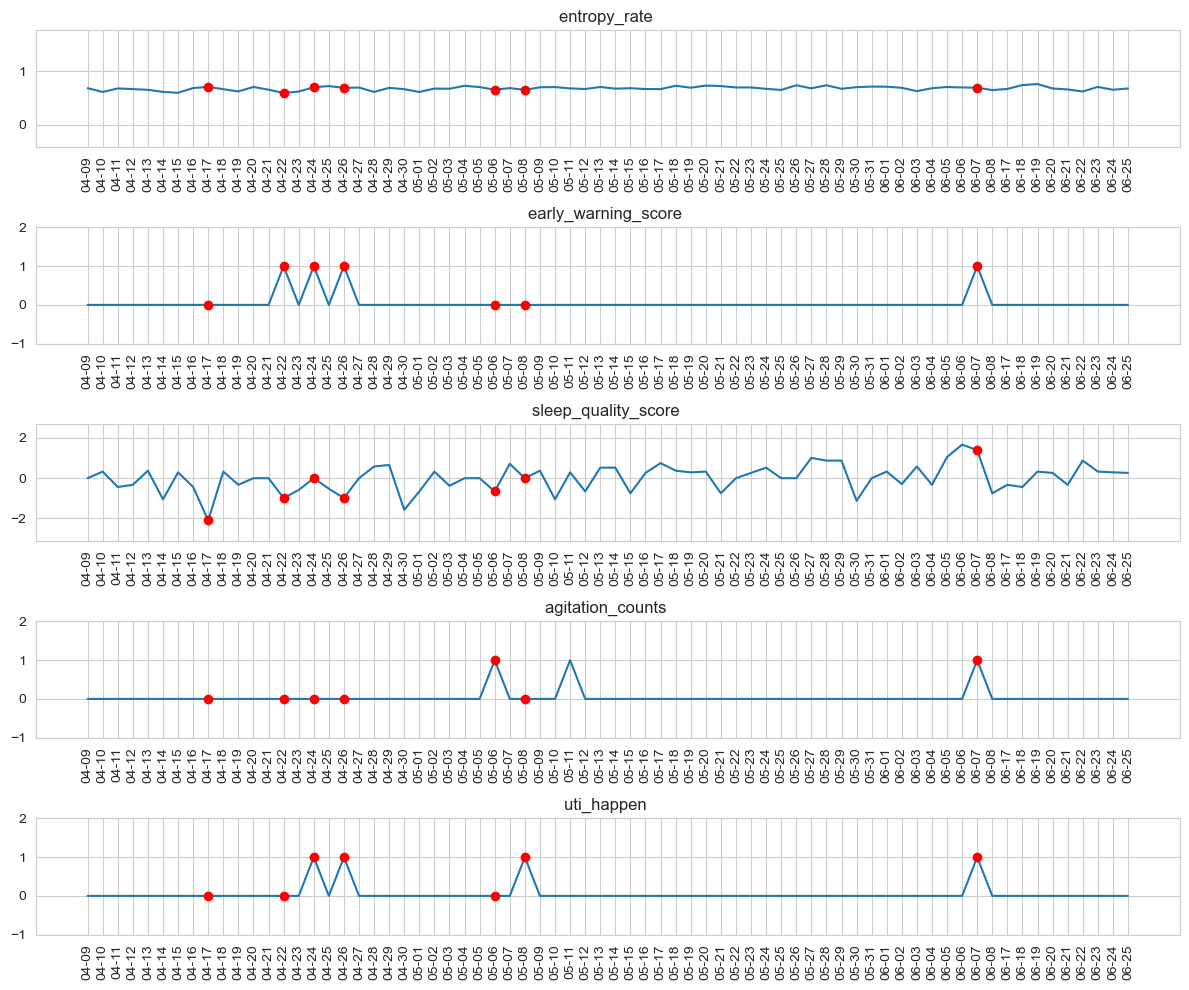

In [8]:
# Set the figure size
plt.figure(figsize=(12, 10))

# Plot each variable
for i, column in enumerate(data_plot.columns):
    plt.subplot(5, 1, i+1)  # 3x3 grid for 7 variables, including empty ones for better arrangement
    plt.plot(data_plot.index, data_plot[column], label=column)
    
    # # Highlight specific index in red
    plt.scatter(anomaly_dates, data_plot[column][anomaly_dates], color='red', label='anomaly', zorder=5)
       
    # Title and labels
    plt.title(f'{column} ')
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)
    
    # Optional: Adjusting the y-axis range to fit all data in the plots
    plt.ylim(data_plot[column].min() - 1, data_plot[column].max() + 1)

# Adjust layout and show plot
plt.tight_layout()

plt.savefig('../output/Anomaly_delirium/forest_isolation/anomaly_ForestIsolation_' + id_select + '.png', dpi=300)
plt.show()

C:\Users\lpxcm13\AppData\Roaming\Python\Python39\site-packages\sklearn\ensemble\_iforest.py:288: UserWarning: max_samples (30) is greater than the total number of samples (4). max_samples will be set to n_samples for estimation.
  warn(
C:\Users\lpxcm13\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\lpxcm13\AppData\Roaming\Python\Python39\site-packages\sklearn\ensemble\_iforest.py:288: UserWarning: max_samples (30) is greater than the total number of samples (13). max_samples will be set to n_samples for estimation.
  warn(
C:\Users\lpxcm13\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\lpxcm13\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feat

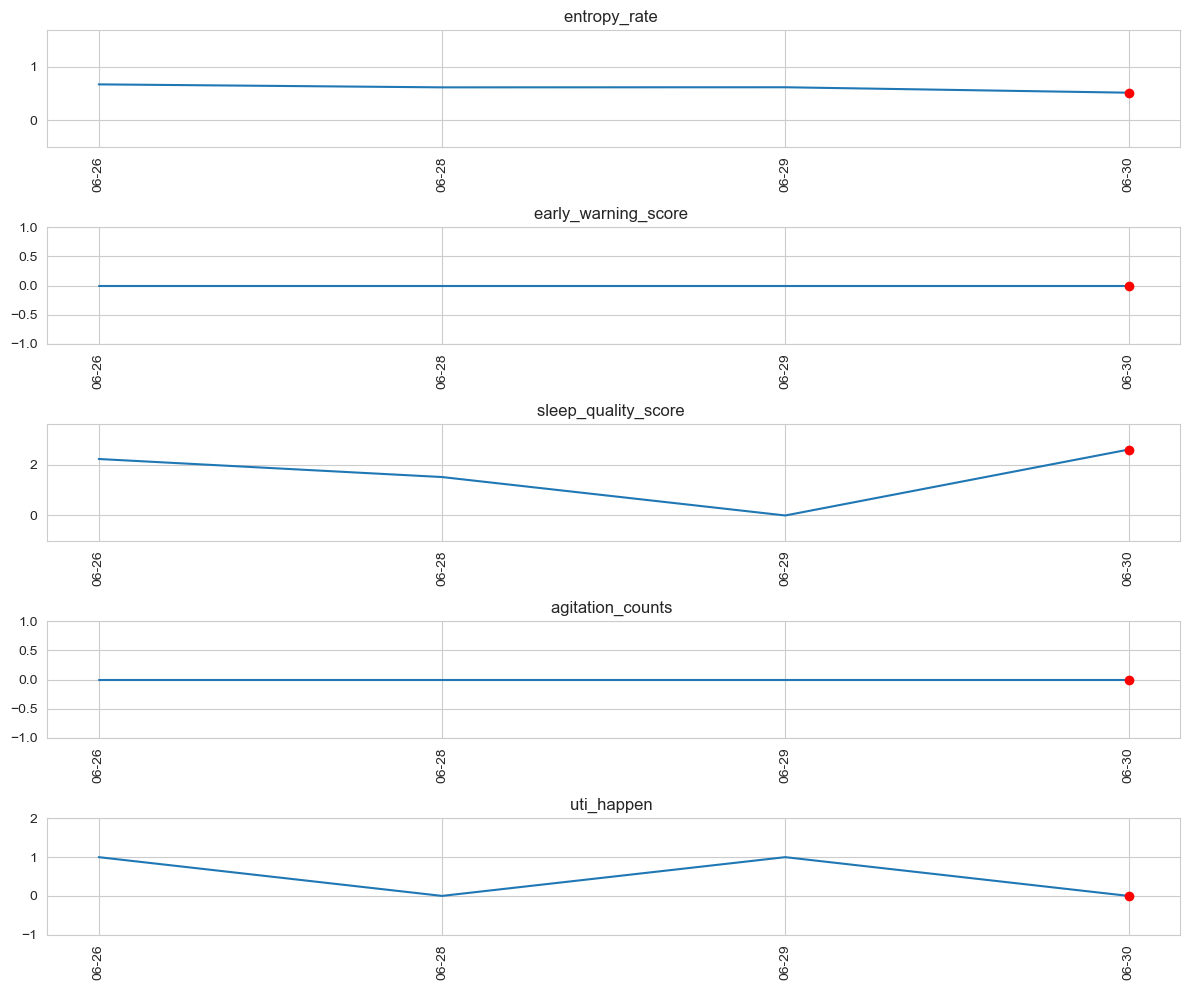

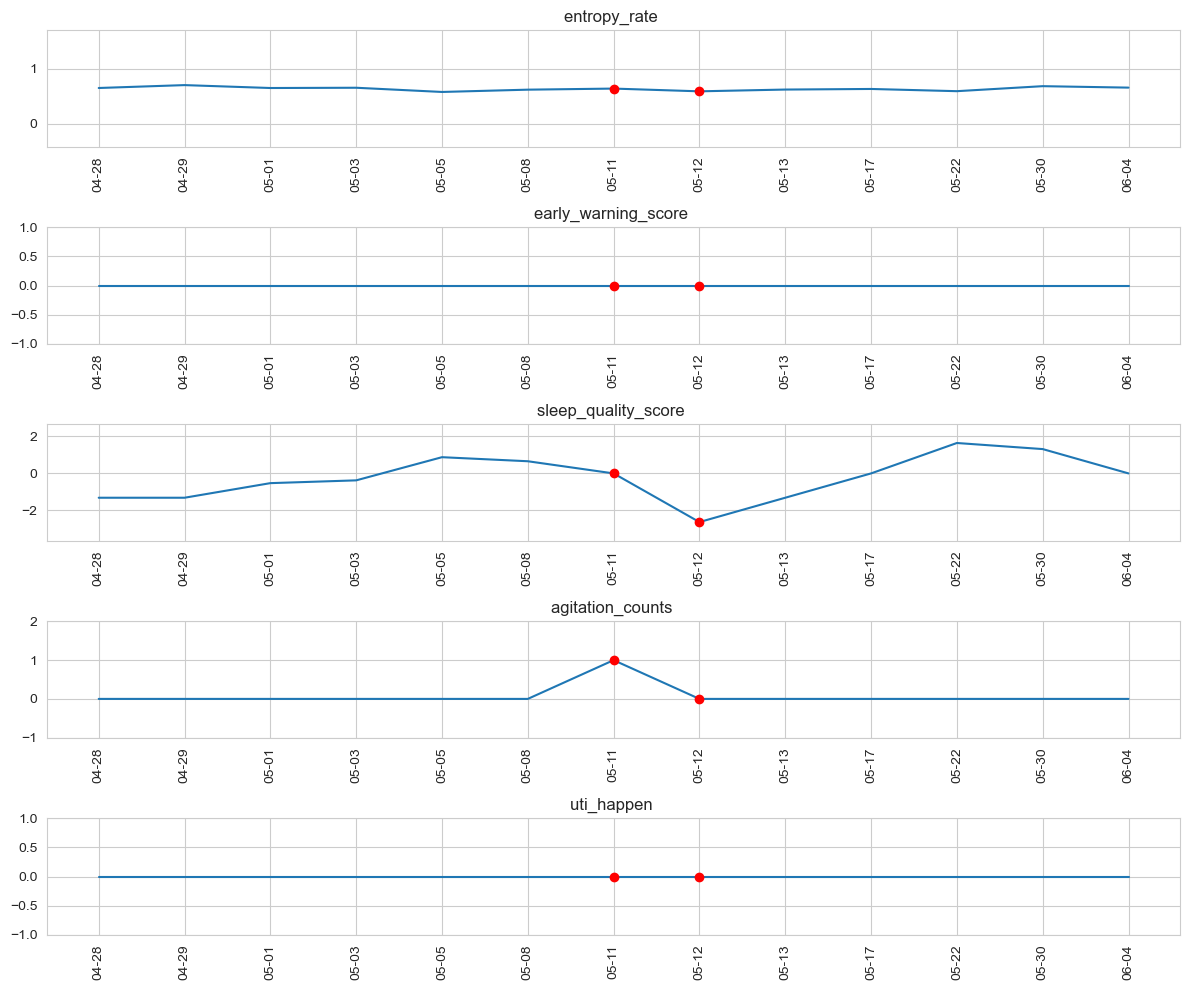

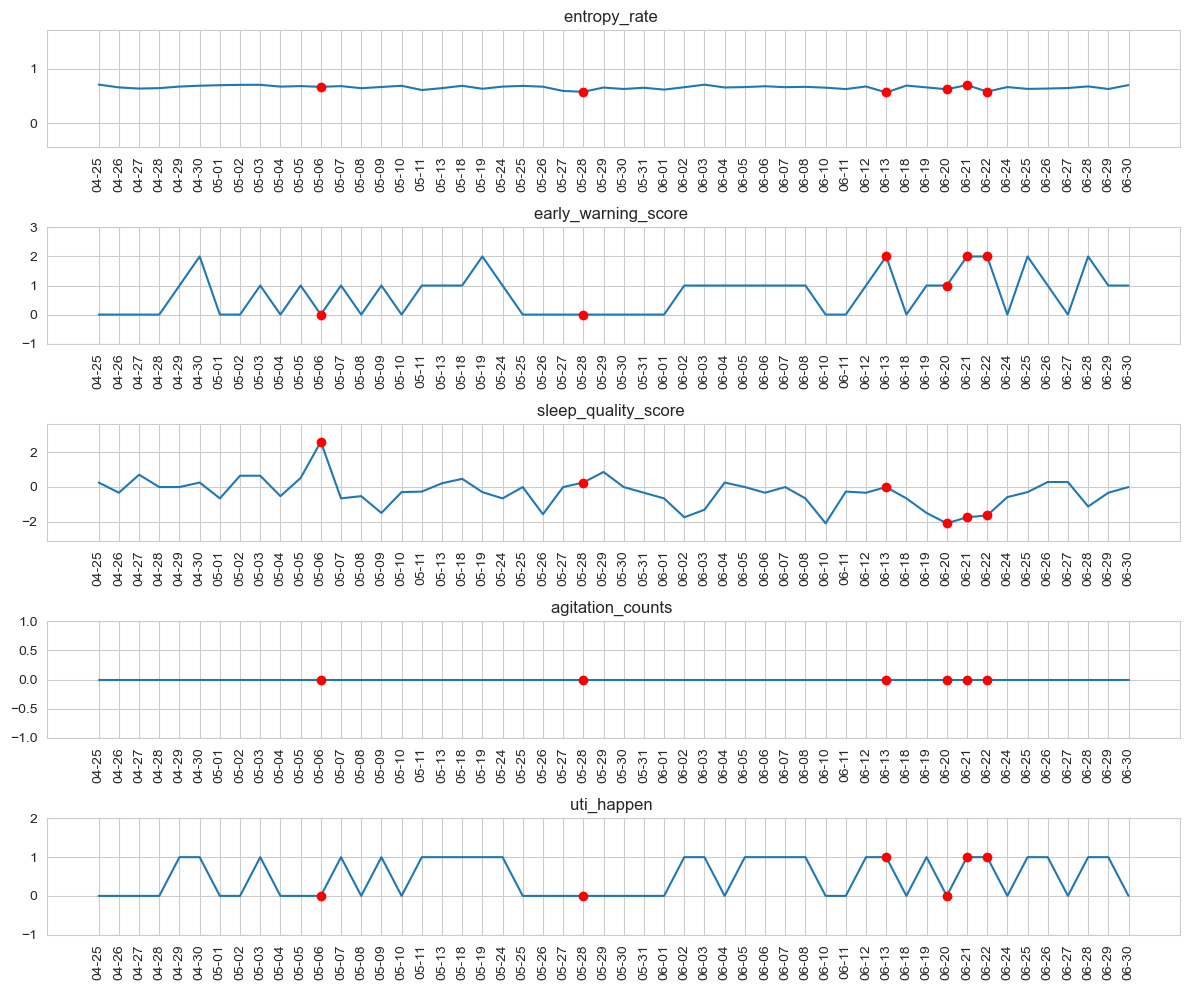

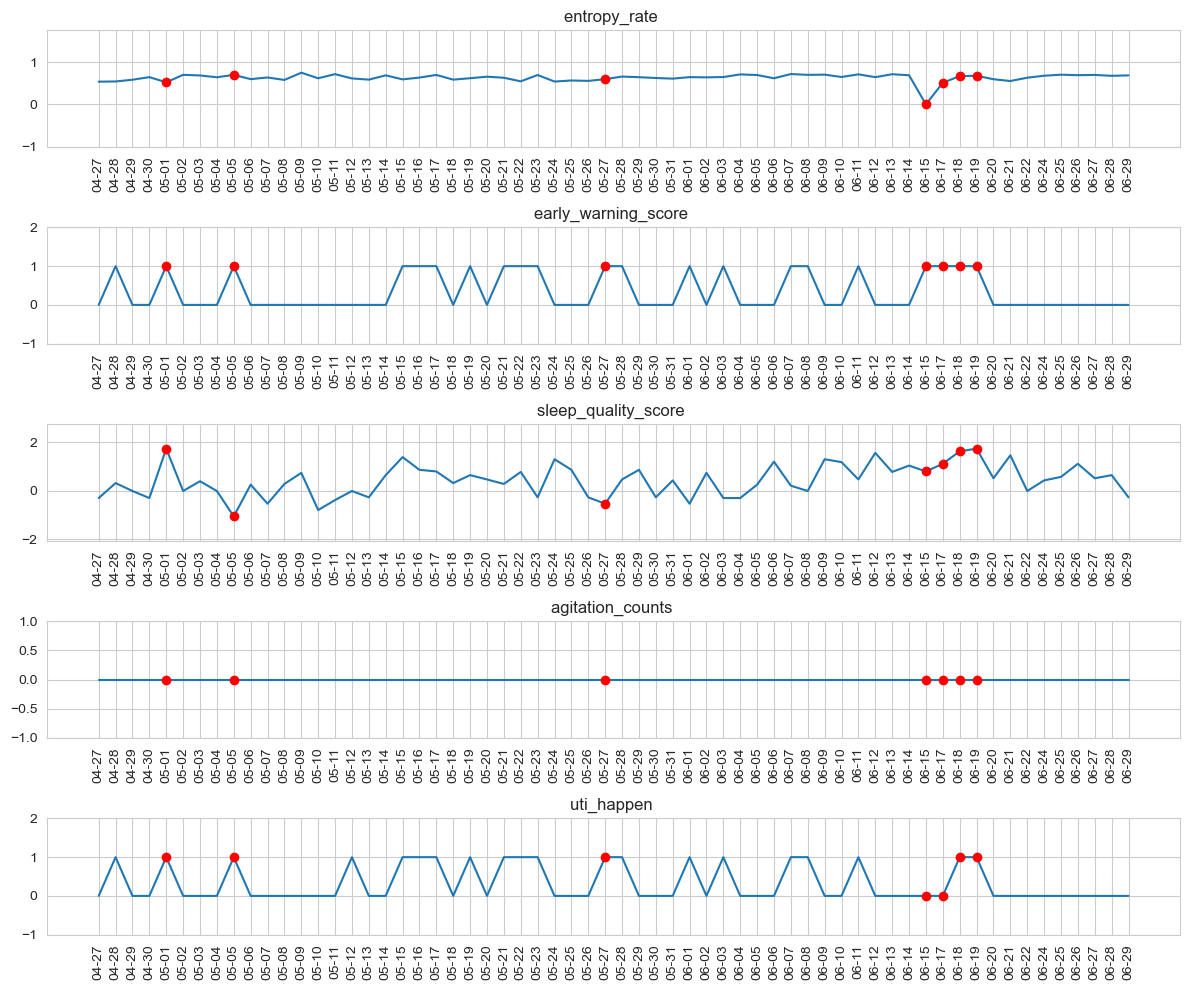

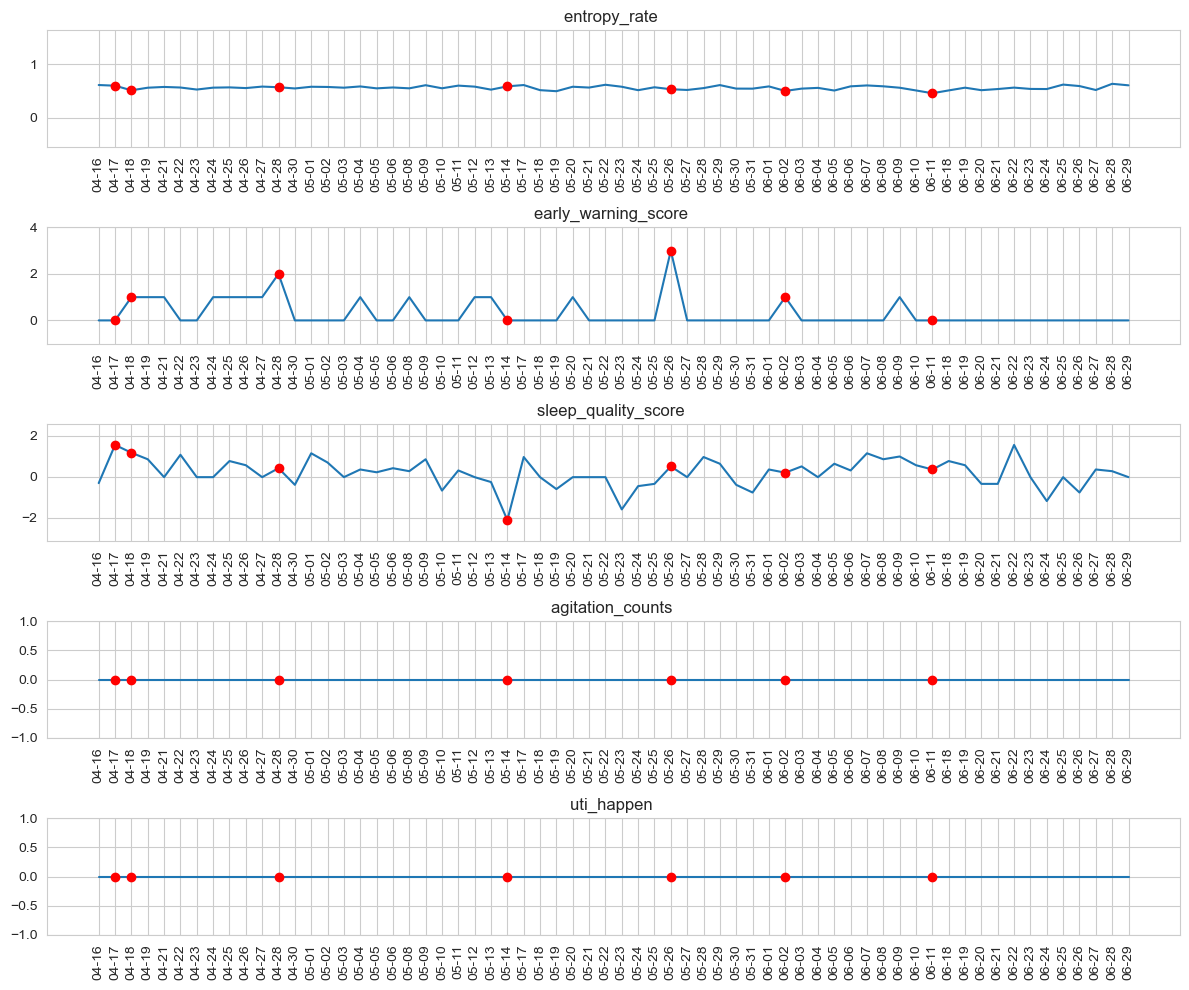

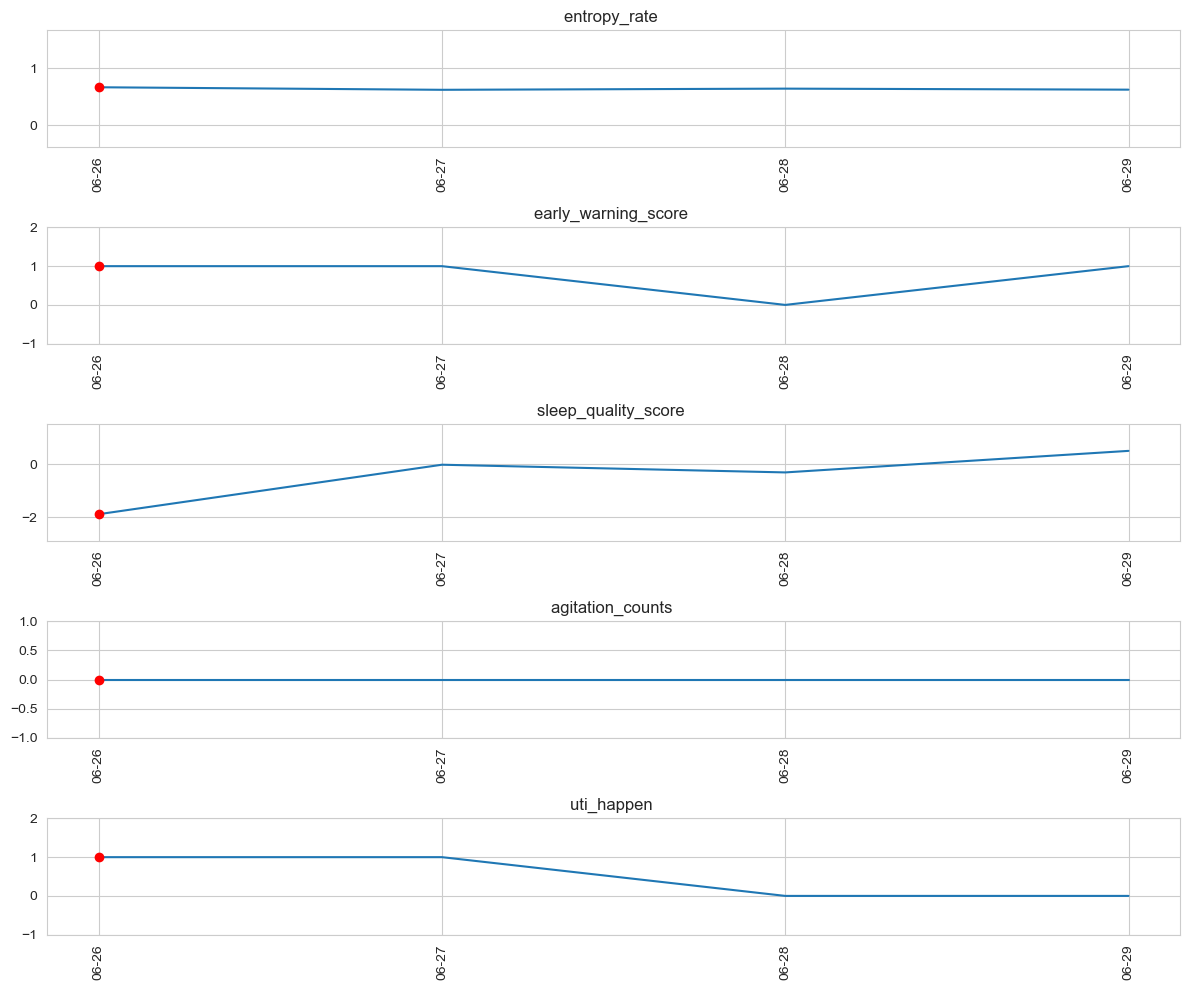

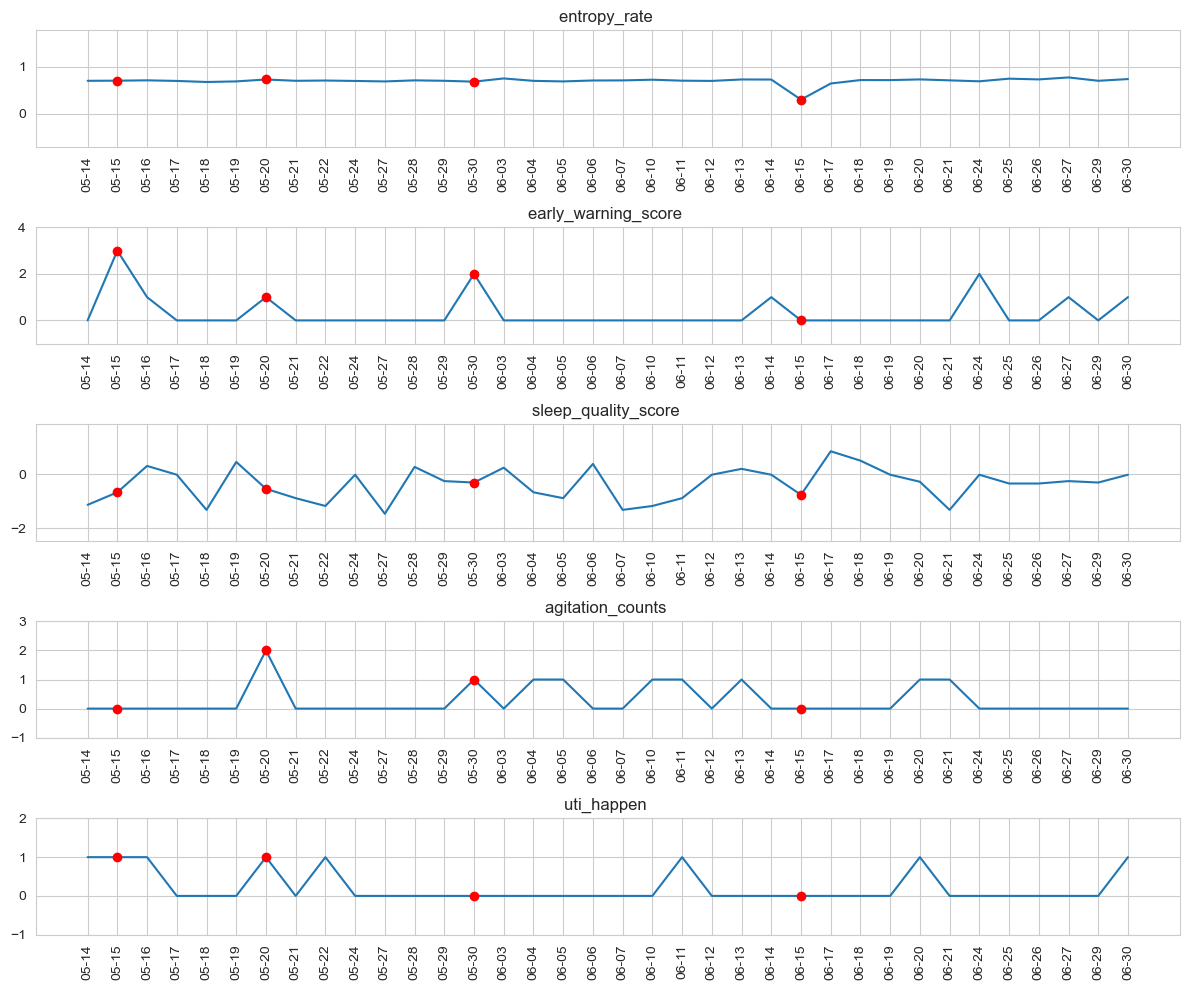

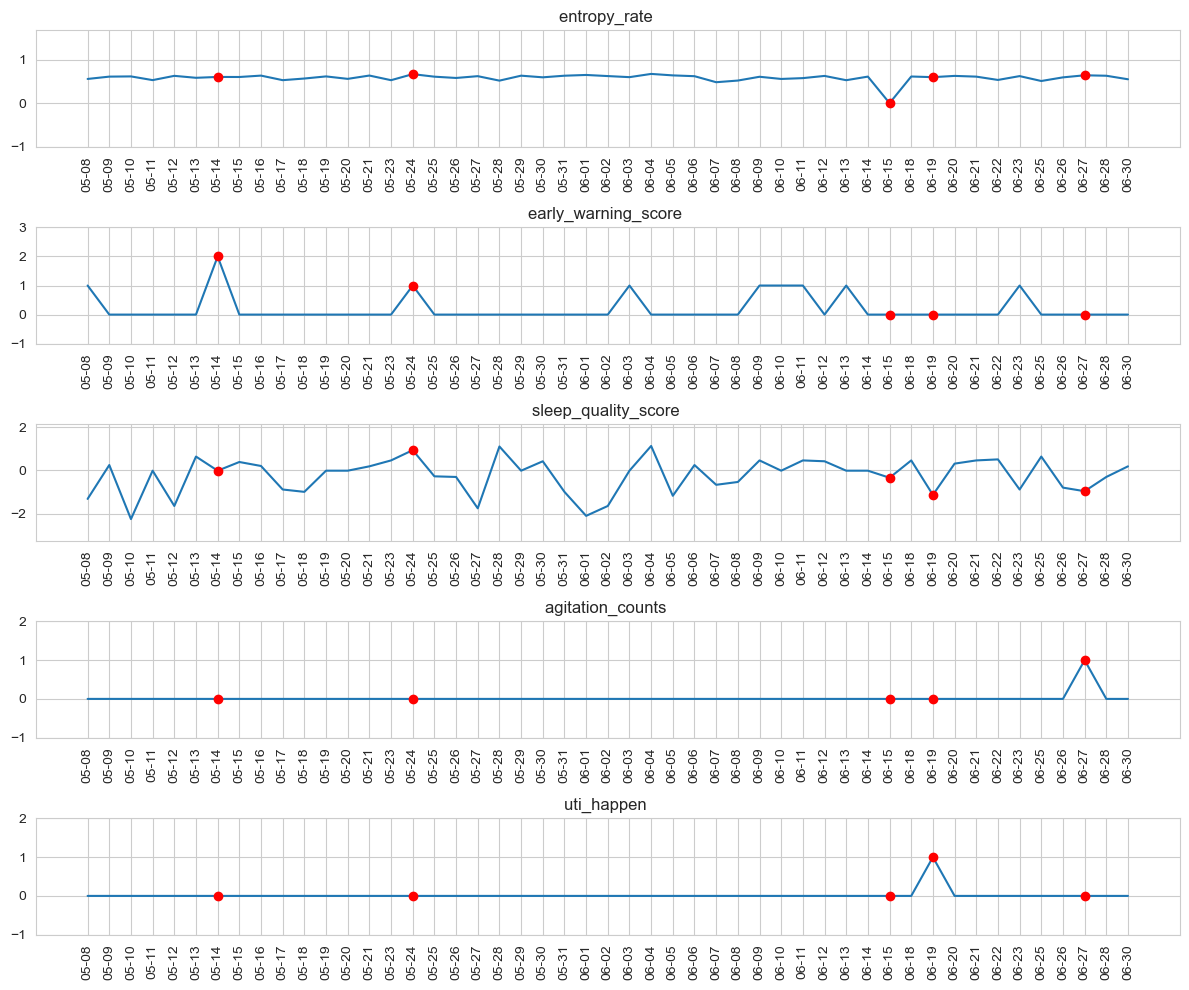

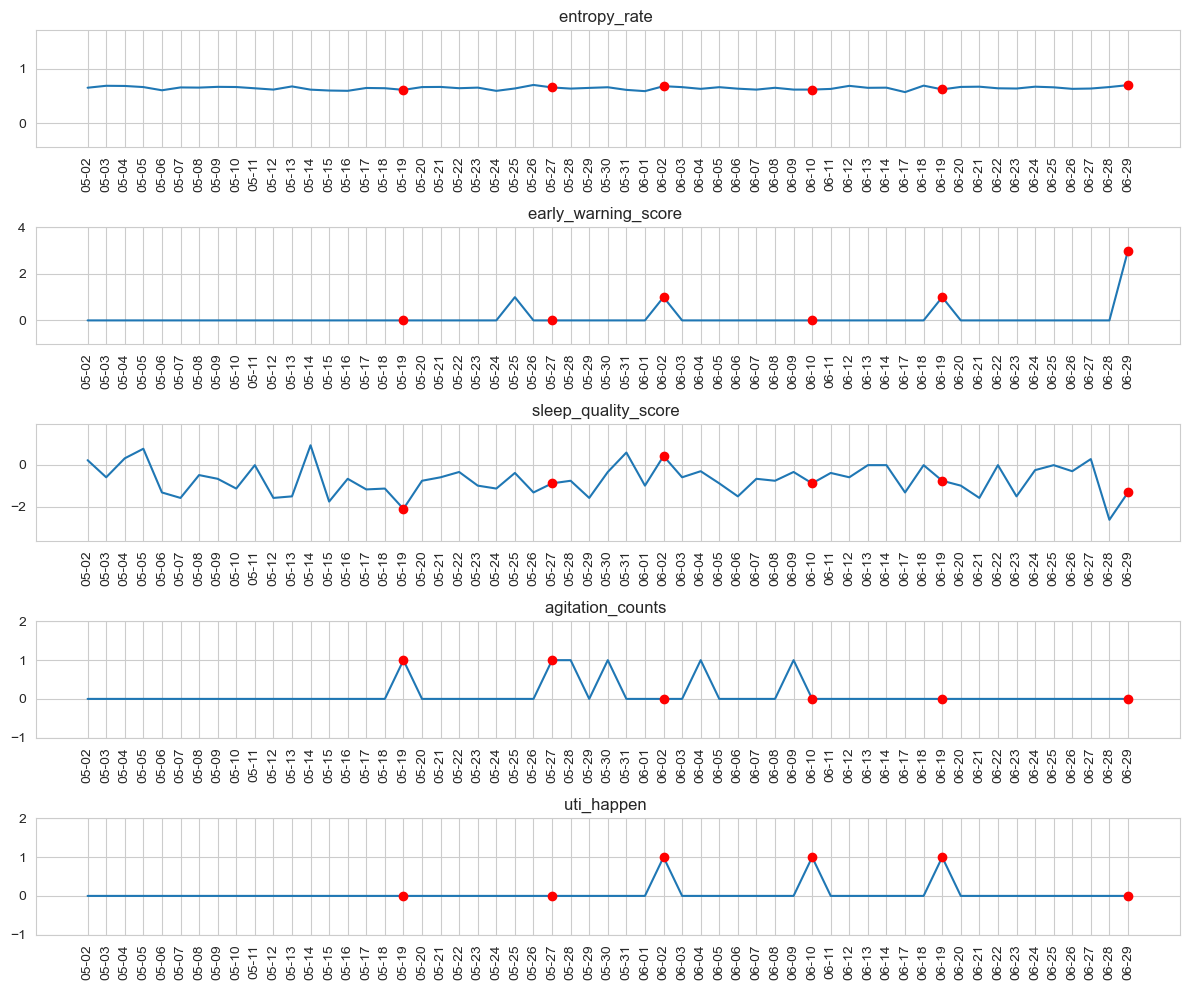

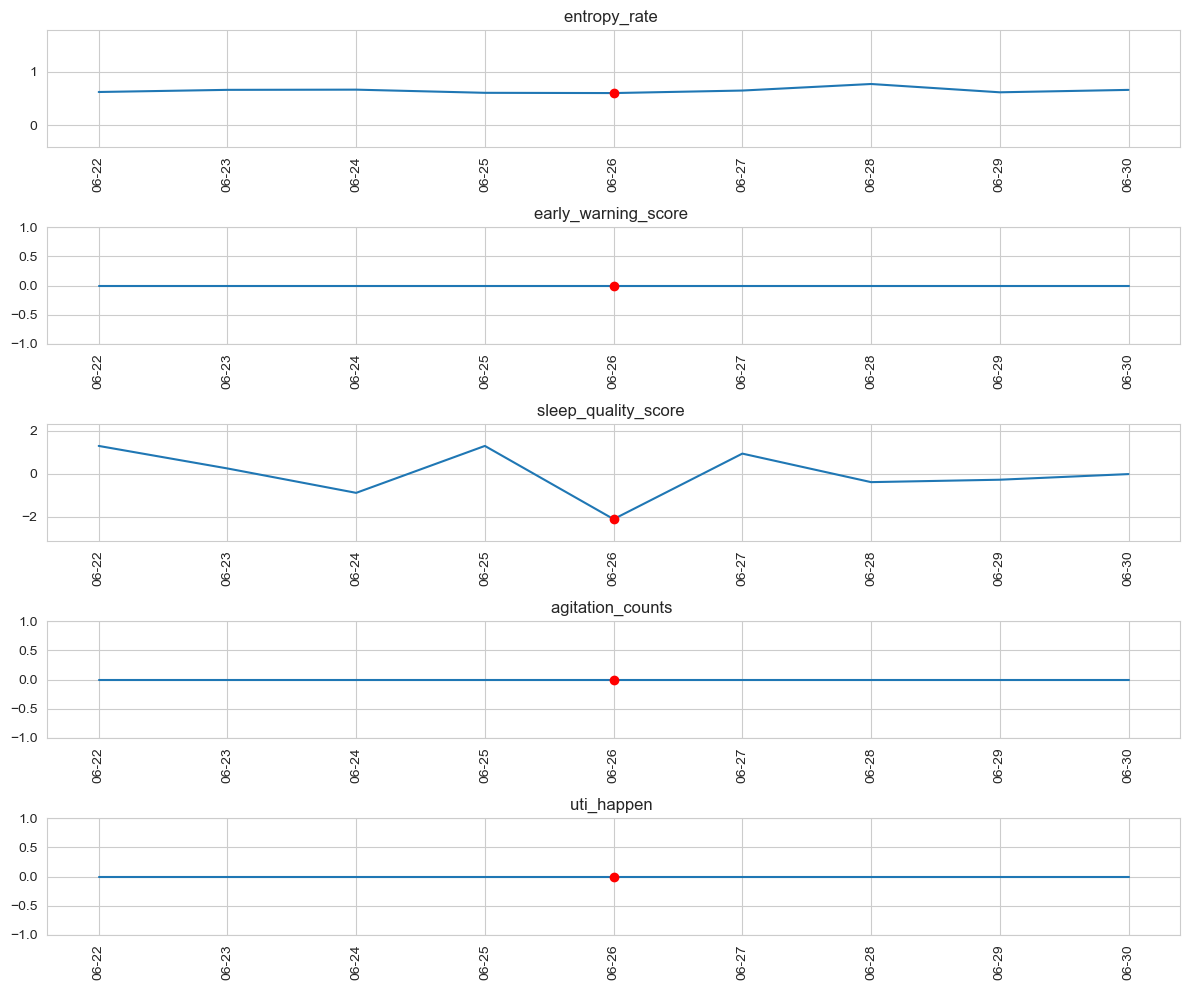

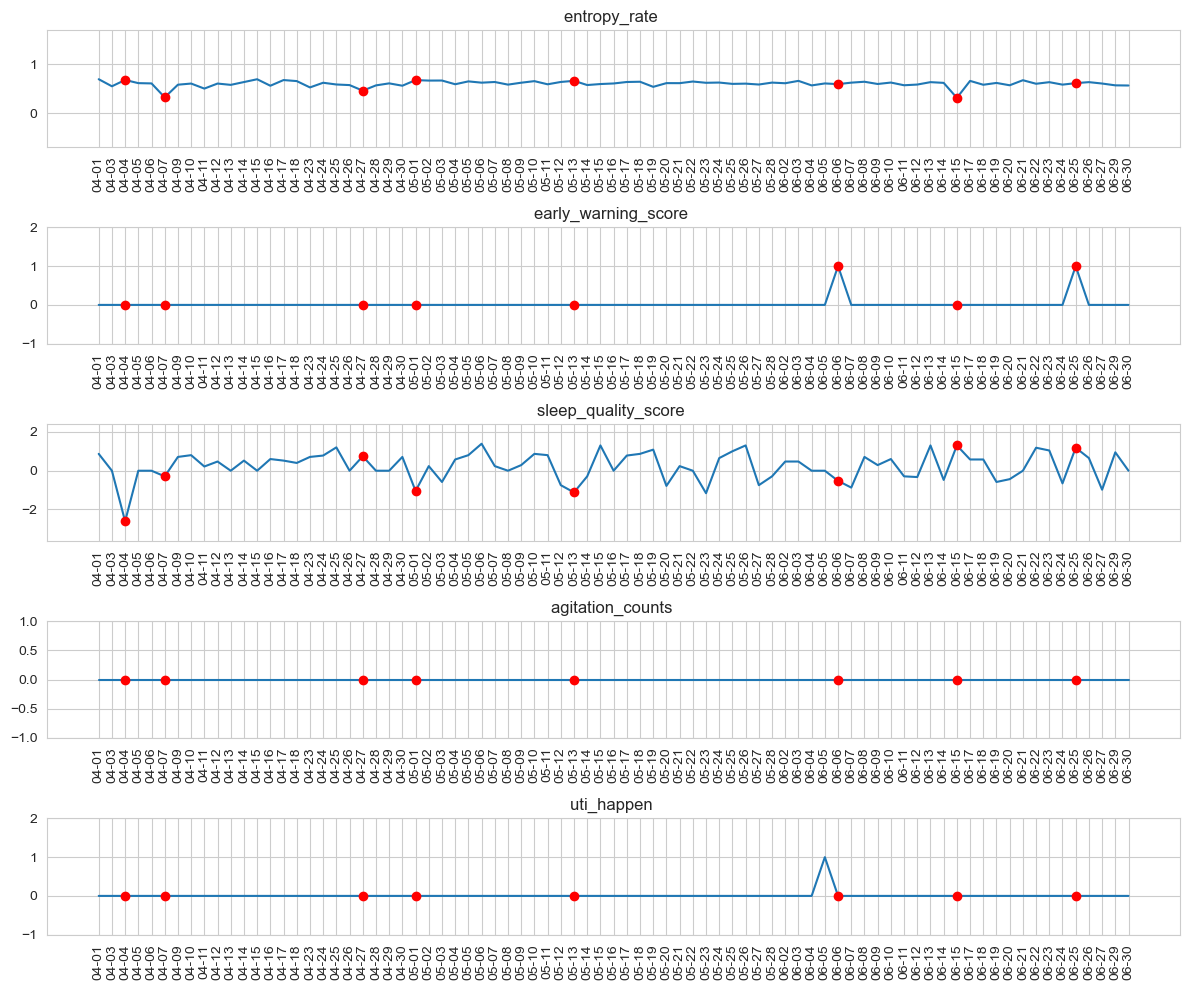

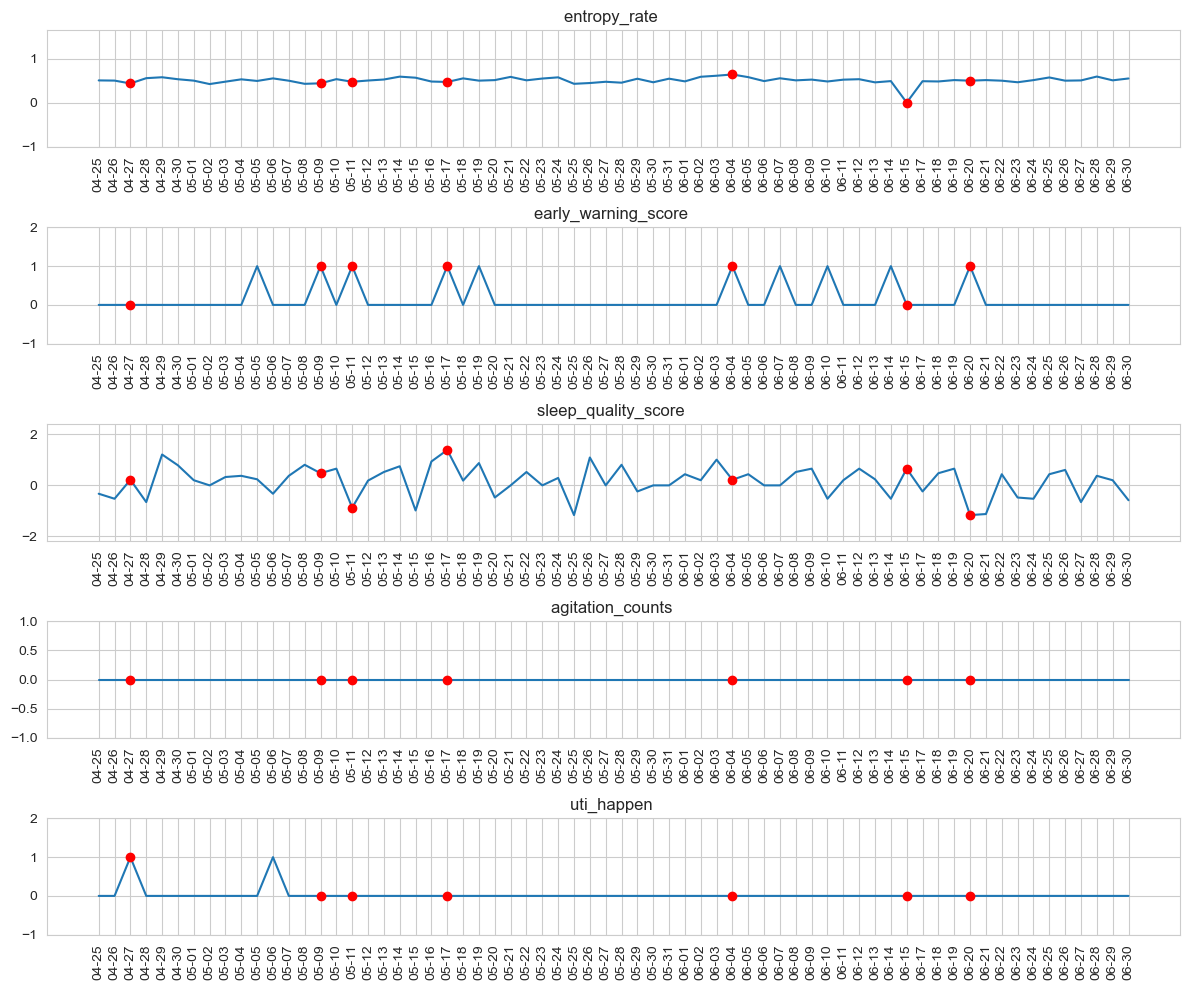

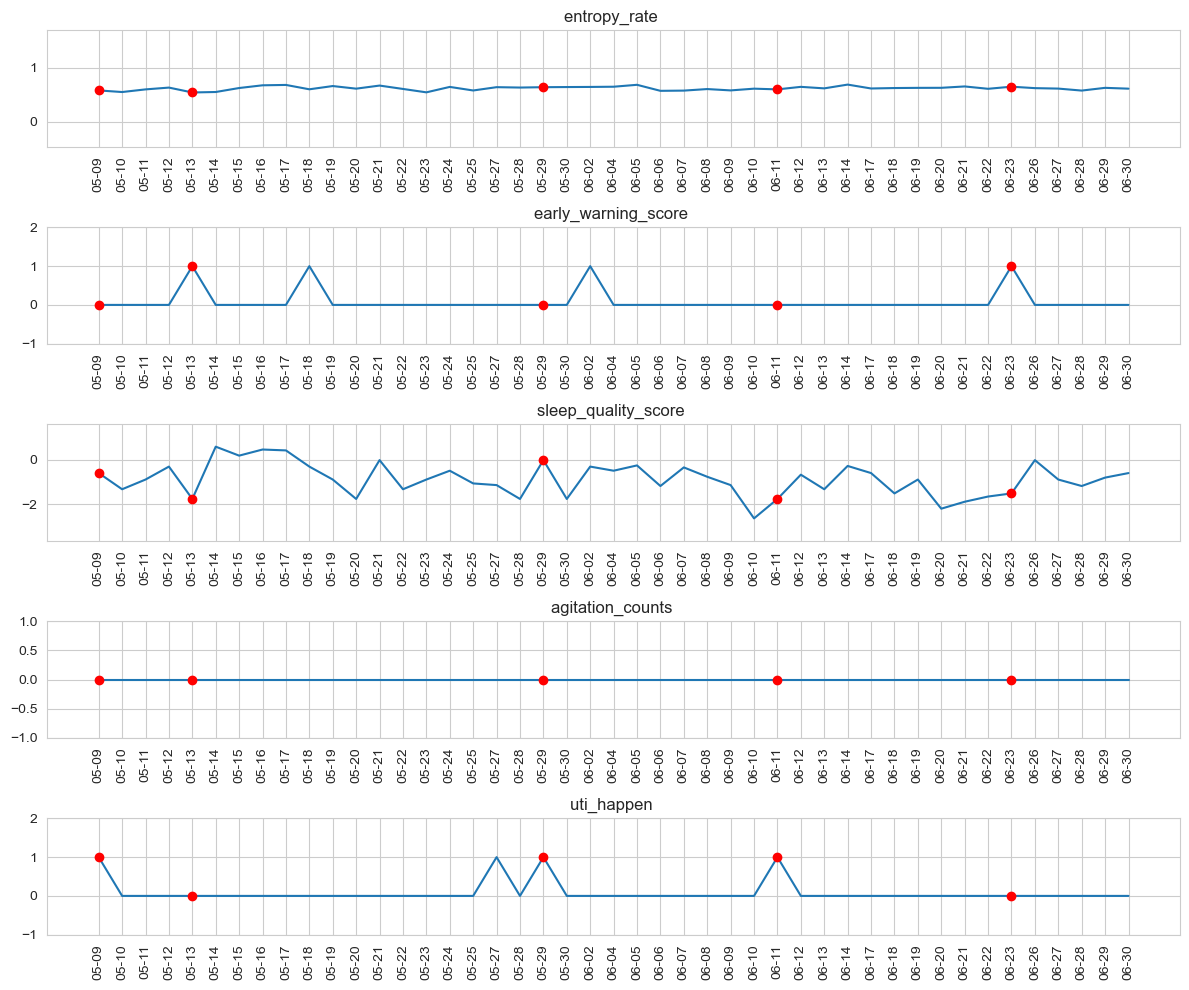

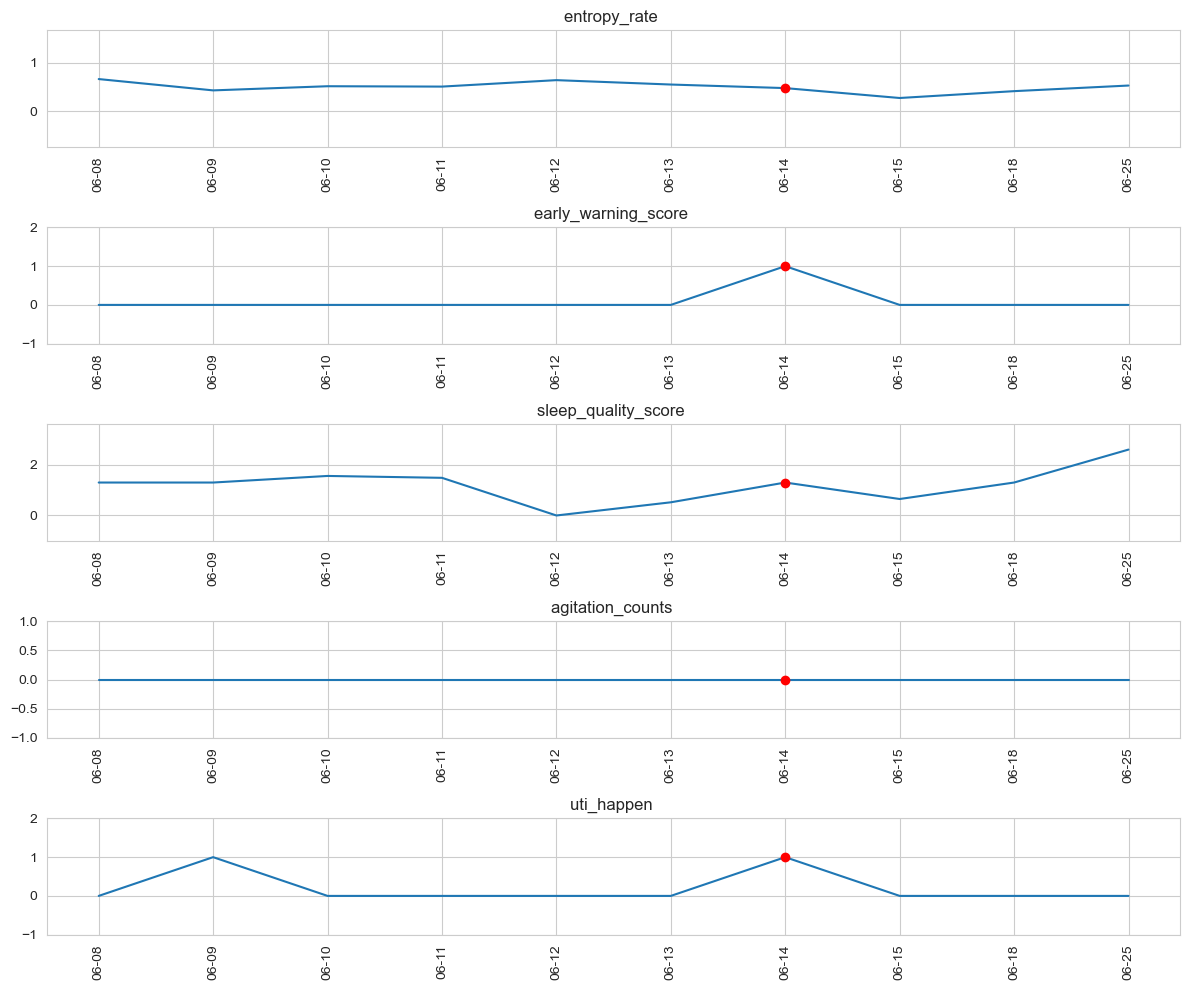

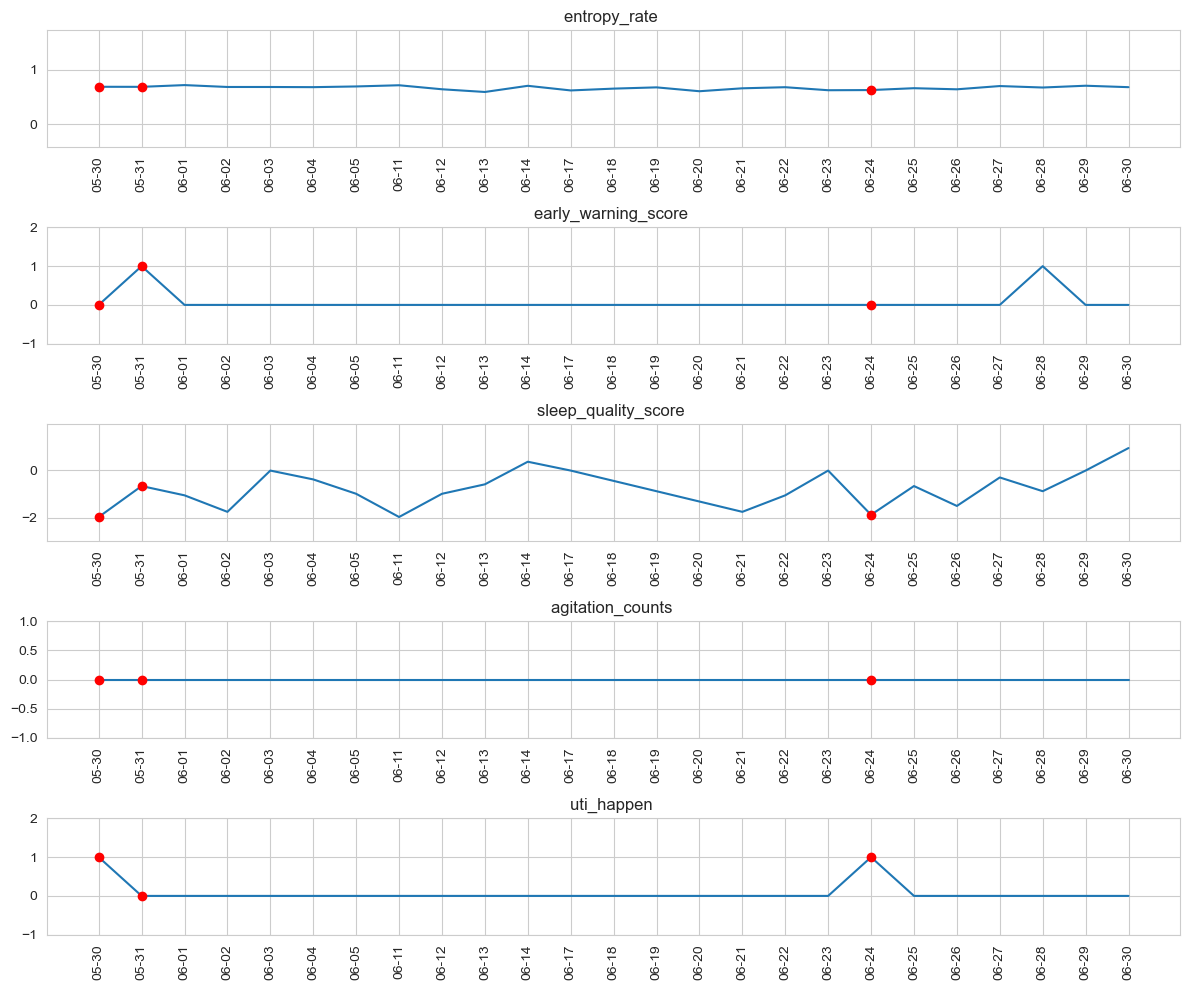

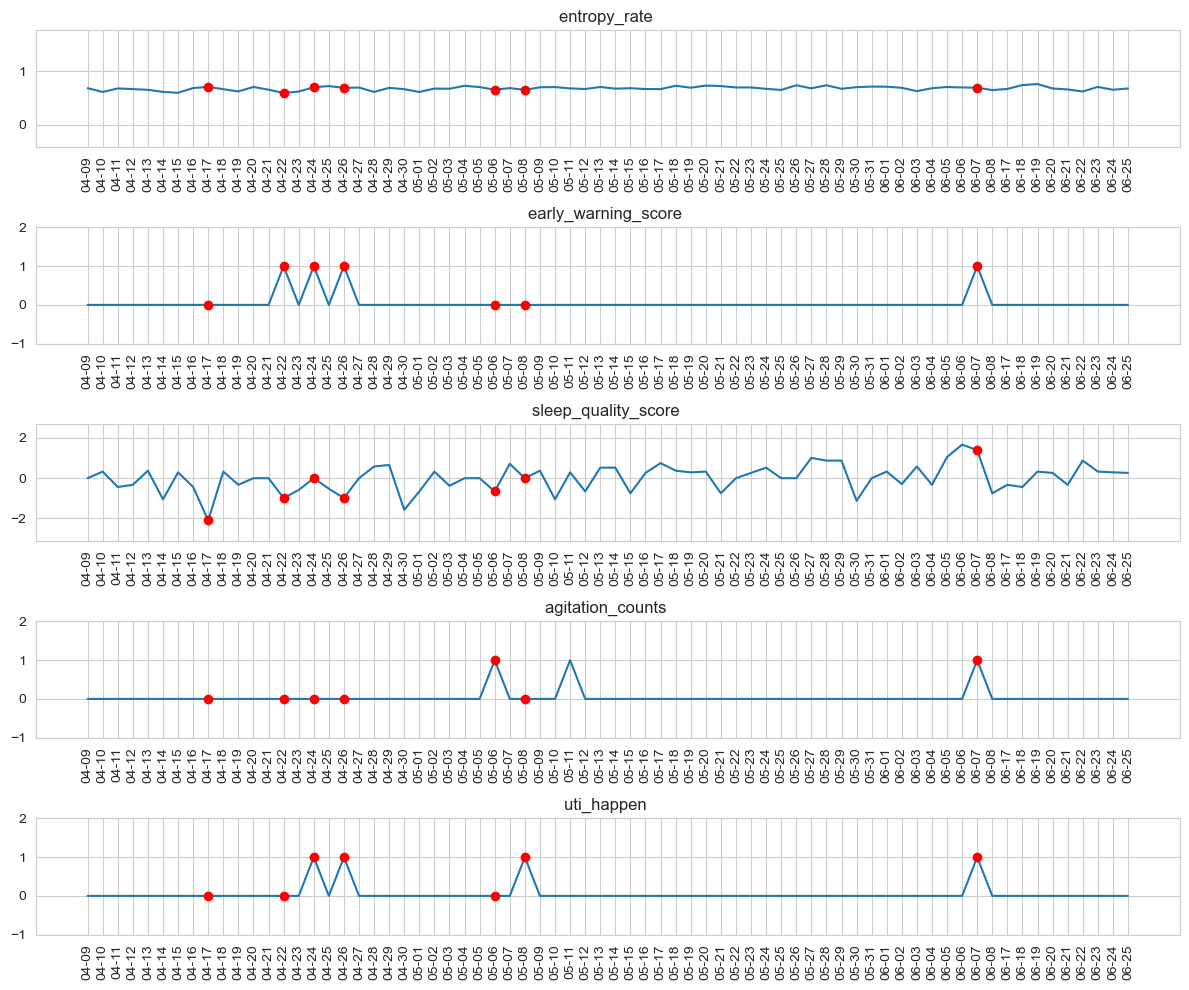

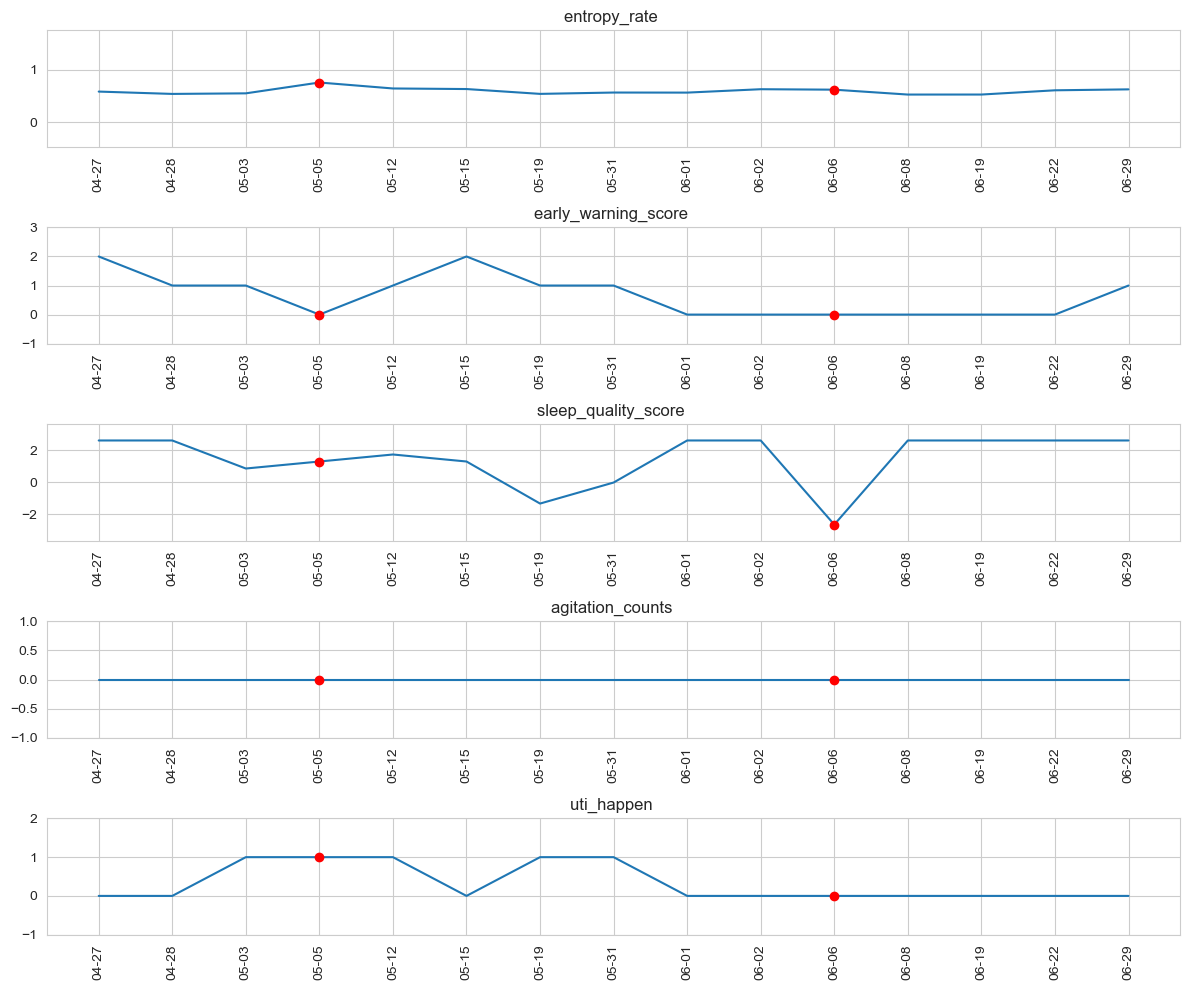

In [10]:
# ALL in One
dfs_anomaly_all = []
for id_select in  analysis_df['patient_id'].unique():
    df_person = analysis_df[analysis_df['patient_id'] == id_select].copy()

    data = df_person.copy()
    features = data[['entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts','uti_happen']] 
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)
    scaled_features_df = pd.DataFrame(scaled_features, columns=features.columns)
    
    # Train Isolation Forest
    iso_forest = IsolationForest(n_estimators=n_estimators,
                                contamination=contamination,
                                max_samples=sample_size,
                                random_state=42)
    
    iso_forest.fit(scaled_features_df)
    
    # Calculate anomaly scores and classify anomalies
    
    data['anomaly_score'] = iso_forest.decision_function(scaled_features_df)
    data['anomaly'] = iso_forest.predict(scaled_features_df)
    anomaly_dates = pd.to_datetime(data[data.anomaly == -1].date).dt.strftime('%m-%d').astype(str).values
    anomaly_df = pd.DataFrame(anomaly_dates, columns = ['date'])
    anomaly_df['patient_id'] = id_select
    dfs_anomaly_all.append(anomaly_df)    

    data_plot = data[['date', 'entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen']].copy()
    
    data_plot['date'] = pd.to_datetime(data_plot['date'])            
    data_plot['date'] = data_plot['date'].dt.strftime('%m-%d')
    data_plot['date'] = data_plot['date'].astype(str)             
    data_plot.set_index('date', inplace=True)
    
    
        # Set the figure size
    plt.figure(figsize=(12, 10))
    
    # Plot each variable
    for i, column in enumerate(data_plot.columns):
        plt.subplot(5, 1, i+1)  # 3x3 grid for 7 variables, including empty ones for better arrangement
        plt.plot(data_plot.index, data_plot[column], label=column)
        
        # # Highlight specific index in red
        plt.scatter(anomaly_dates, data_plot[column][anomaly_dates], color='red', label='anomaly', zorder=5)
           
        # Title and labels
        plt.title(f'{column} ')
        plt.xlabel('')
        plt.ylabel('')
        plt.xticks(rotation=90)
        
        # Optional: Adjusting the y-axis range to fit all data in the plots
        plt.ylim(data_plot[column].min() - 1, data_plot[column].max() + 1)
    
    # Adjust layout and show plot
    plt.tight_layout()
    
    plt.savefig('../output/Anomaly_delirium/forest_isolation/anomaly_ForestIsolation_' + id_select + '.png', dpi=300)
    
dfs_anomaly_all = pd.concat(dfs_anomaly_all, ignore_index=True)   
dfs_anomaly_all.to_csv("../output/Anomaly_delirium/forest_isolation/forest_isolation_anomaly_data.csv", index=False)

In [11]:
dfs_anomaly_all

,date,patient_id
0,06-30,0f352
1,05-11,16f4b
2,05-12,16f4b
3,05-06,1fbe4
4,05-28,1fbe4
...,...,...
68,05-06,ec812
69,05-08,ec812
70,06-07,ec812
71,05-05,f220c
